## Exercice 1 — Analyse de données Netflix (Pandas + Matplotlib)

In [1]:
import pandas as pd

#charger le fichier csv
netflix = pd.read_csv('netflix.csv', index_col=0)

#### Partie 1 - Vérifier le chargement du DataFrame

In [2]:
print(f"""shape du DataFrame: {netflix.shape}
nb lignes DataFrame: {netflix.shape[0]}
nb colonnes DataFrame: {netflix.shape[1]}""")

print(netflix.head())

shape du DataFrame: (8807, 11)
nb lignes DataFrame: 8807
nb colonnes DataFrame: 11
            type                  title         director  \
show_id                                                    
s1         Movie   Dick Johnson Is Dead  Kirsten Johnson   
s2       TV Show          Blood & Water              NaN   
s3       TV Show              Ganglands  Julien Leclercq   
s4       TV Show  Jailbirds New Orleans              NaN   
s5       TV Show           Kota Factory              NaN   

                                                      cast        country  \
show_id                                                                     
s1                                                     NaN  United States   
s2       Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
s3       Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
s4                                                     NaN            NaN   
s5       Mayur More, Jitendra Kuma

#### Partie 2 — Analyse

In [3]:
from datetime import datetime
import numpy as np


def normalize_date(date):
    if pd.isna(date):
        return date
    else:
        return datetime.strptime(str(date).strip(), "%B %d, %Y")

netflix['normalized_date_added'] = netflix['date_added'].apply(normalize_date)

most_recent_mov = netflix[np.logical_and(
    netflix['type'] == 'Movie',
    netflix['normalized_date_added'] == netflix['normalized_date_added'].max()
)]

## afficher le film le plus récent
print(most_recent_mov)

          type                 title         director cast        country  \
show_id                                                                     
s1       Movie  Dick Johnson Is Dead  Kirsten Johnson  NaN  United States   

                 date_added  release_year rating duration      listed_in  \
show_id                                                                    
s1       September 25, 2021          2020  PG-13   90 min  Documentaries   

                                               description  \
show_id                                                      
s1       As her father nears the end of his life, filmm...   

        normalized_date_added  
show_id                        
s1                 2021-09-25  


In [4]:
## le nombre de films vs séries

#check types which exist
print(netflix['type'].unique())

print()
print(f'nombre de films: {len(netflix[netflix['type'] == 'Movie'])}')
print(f'nombre de séries: {len(netflix[netflix['type'] == 'TV Show'])}')

['Movie' 'TV Show']

nombre de films: 6131
nombre de séries: 2676


In [5]:
def count_occu(input, output_dict={}, reversed=True):
    for row in input:
        for c in str(row).split(','):
            try:
                output_dict[c.strip()] += 1
            
            except KeyError:
                output_dict[c.strip()] = 1

    return sorted(output_dict.items(), key=lambda x: x[1], reverse=reversed)

In [6]:
## les 5 pays les plus fréquents

sorted_countries = count_occu(netflix['country'].unique())

print('Liste des 5 pays les plus fréquents')
print(sorted_countries[:5])

Liste des 5 pays les plus fréquents
[('United States', 359), ('United Kingdom', 207), ('France', 177), ('Canada', 117), ('Germany', 116)]


In [7]:
# les genres les plus fréquents

sorted_genres = count_occu(netflix['listed_in'].unique())
print('Liste des 5 pays les plus fréquents')
print(sorted_genres[:5])

Liste des 5 pays les plus fréquents
[('United States', 359), ('United Kingdom', 207), ('France', 177), ('Canada', 117), ('Germany', 116)]


#### Partie 3 — Filtrage

In [8]:
# films après 2015

mov_aft_2015 = netflix[np.logical_and(
    netflix['type'] == 'Movie',
    netflix['release_year'] > 2015
)]
print(mov_aft_2015)

          type                             title  \
show_id                                            
s1       Movie              Dick Johnson Is Dead   
s7       Movie  My Little Pony: A New Generation   
s10      Movie                      The Starling   
s13      Movie                      Je Suis Karl   
s14      Movie  Confessions of an Invisible Girl   
...        ...                               ...   
s8782    Movie           Yo-Kai Watch: The Movie   
s8783    Movie                       Yoga Hosers   
s8787    Movie                      You Can Tutu   
s8788    Movie         You Can’t Fight Christmas   
s8795    Movie                            اشتباك   

                              director  \
show_id                                  
s1                     Kirsten Johnson   
s7       Robert Cullen, José Luis Ucha   
s10                     Theodore Melfi   
s13                Christian Schwochow   
s14                      Bruno Garotti   
...                          

In [9]:
# series_USA
series_USA = netflix[np.logical_and(
    netflix.loc[:, 'type'] == 'TV Show',
    netflix.loc[:, 'country'].apply(lambda x: str(x).strip()) == 'United States'
)]
print(series_USA)

            type                                   title director  \
show_id                                                             
s16      TV Show                       Dear White People      NaN   
s41      TV Show  He-Man and the Masters of the Universe      NaN   
s56      TV Show                               Nailed It      NaN   
s68      TV Show                       Saved by the Bell      NaN   
s83      TV Show                                 Lucifer      NaN   
...          ...                                     ...      ...   
s8711    TV Show                                   Weeds      NaN   
s8727    TV Show                    When Calls the Heart      NaN   
s8748    TV Show                               Winsanity      NaN   
s8756    TV Show                       Women Behind Bars      NaN   
s8781    TV Show                            Yo-Kai Watch      NaN   

                                                      cast        country  \
show_id                  

In [10]:
# films_action
films_action = netflix[np.logical_and(
    netflix['type'] == 'Movie',
    netflix['listed_in'].apply(lambda x: str(x).lower().find('action')) != -1
)]
print(films_action)

          type                          title          director  \
show_id                                                           
s37      Movie                 The Stronghold    Cédric Jimenez   
s39      Movie            Birth of the Dragon      George Nolfi   
s42      Movie                           Jaws  Steven Spielberg   
s44      Movie                         Jaws 3         Joe Alves   
s45      Movie              Jaws: The Revenge    Joseph Sargent   
...        ...                            ...               ...   
s8767    Movie                            XXx         Rob Cohen   
s8768    Movie        XXX: State of the Union      Lee Tamahori   
s8773    Movie          Yamla Pagla Deewana 2    Sangeeth Sivan   
s8791    Movie  You Don't Mess with the Zohan      Dennis Dugan   
s8793    Movie                    Young Tiger            Mu Chu   

                                                      cast  \
show_id                                                      
s37 

#### Partie 4 — Visualisation

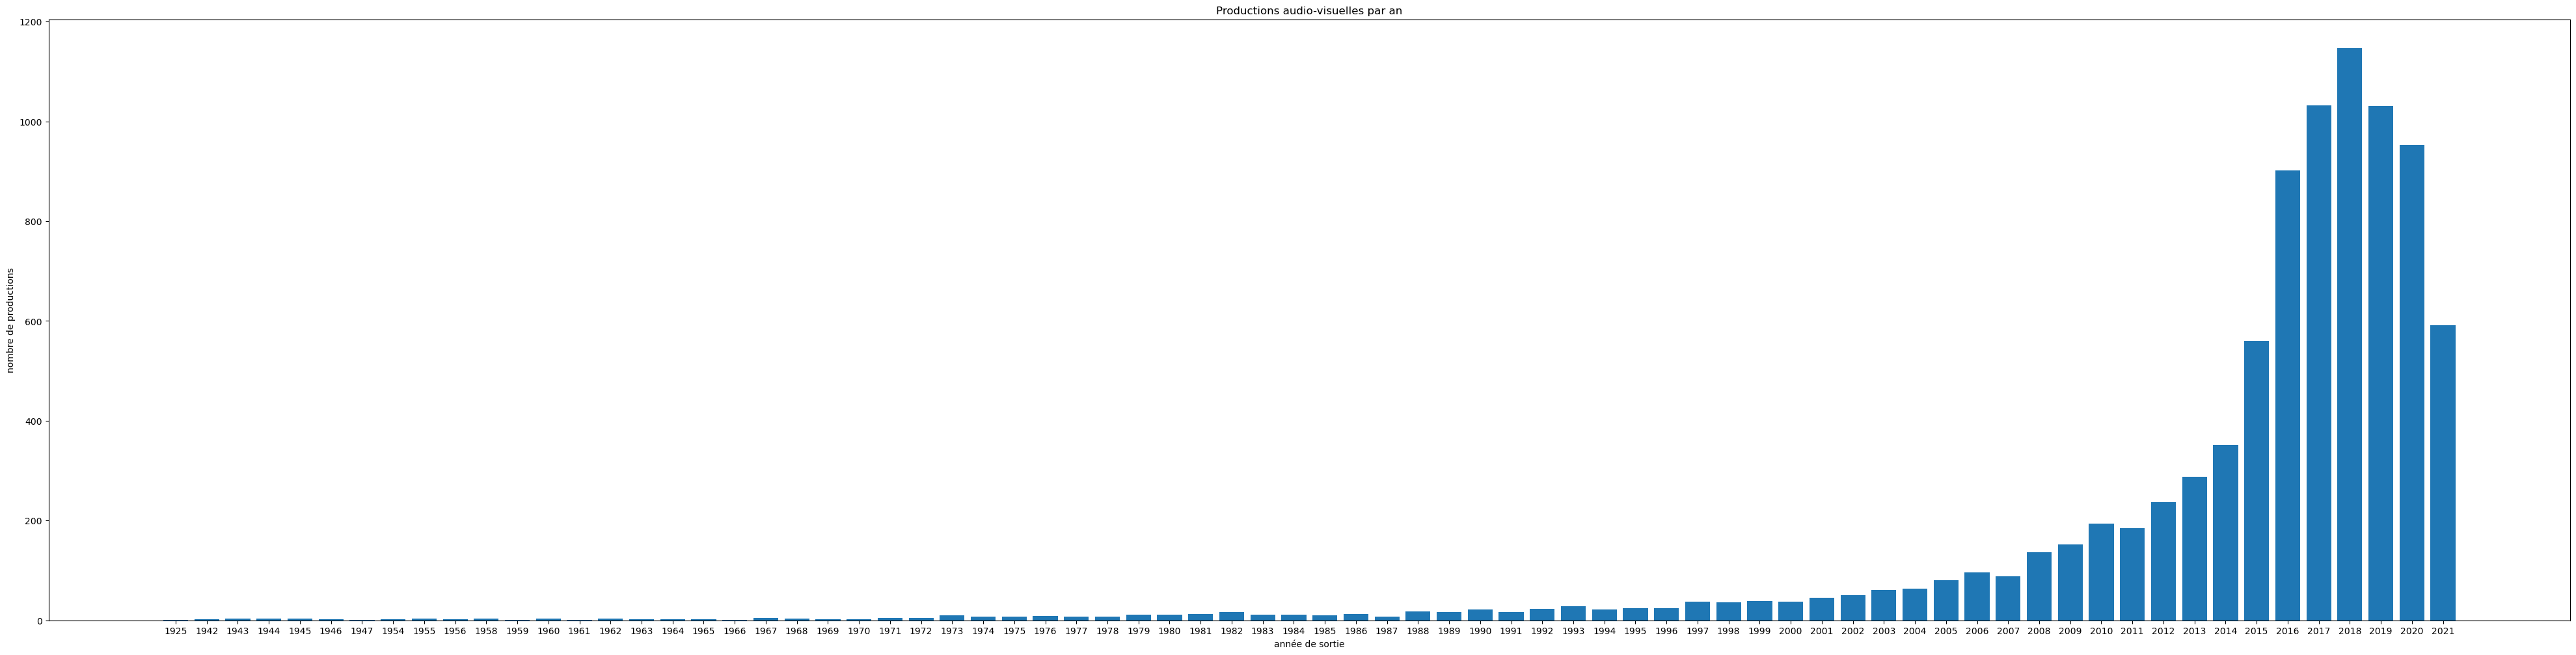

In [11]:
import matplotlib.pyplot as plt

#histogramme des années de sortie

nb_prod_per_year = {str(year): len(netflix[netflix['release_year'] == year]) for year in sorted(netflix['release_year'].unique(), key=lambda x: int(x))}

plt.figure(figsize=(50, 12))
plt.bar(nb_prod_per_year.keys(), nb_prod_per_year.values())
plt.xlabel('année de sortie')
plt.ylabel('nombre de productions')
plt.title('Productions audio-visuelles par an')

plt.savefig('Netflix - Productions audio-visuelles par an')
plt.show()

<Figure size 640x480 with 0 Axes>

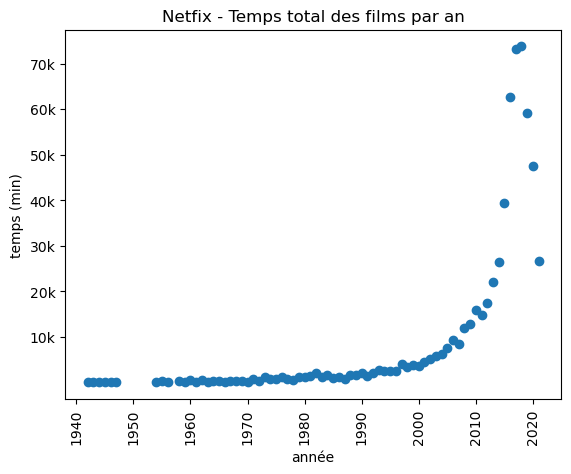

In [12]:
#scatter plot : année vs durée

films = netflix[netflix['type'] == 'Movie']

def curate(duration):
    return int(str(duration).strip().split()[0]) if pd.notna(duration) else 0

duration_per_year = {str(year): films[films['release_year'] == year]
                         .loc[:,'duration']
                         .apply(curate)
                         .sum()
                     for year in sorted(films['release_year'].unique(), key=lambda x: int(x))
}
plt.clf()
plt.figure()
plt.scatter([int(y) for y in duration_per_year.keys()], duration_per_year.values())
plt.xlabel('année')
plt.ylabel('temps (min)')
plt.title('Netfix - Temps total des films par an')
plt.tick_params('x', rotation=90)
plt.yticks(ticks=[t for t in range(10000, 70001, 10000)], labels=[str(l) + 'k' for l in range(10, 71, 10)])
plt.show()

<Figure size 640x480 with 0 Axes>

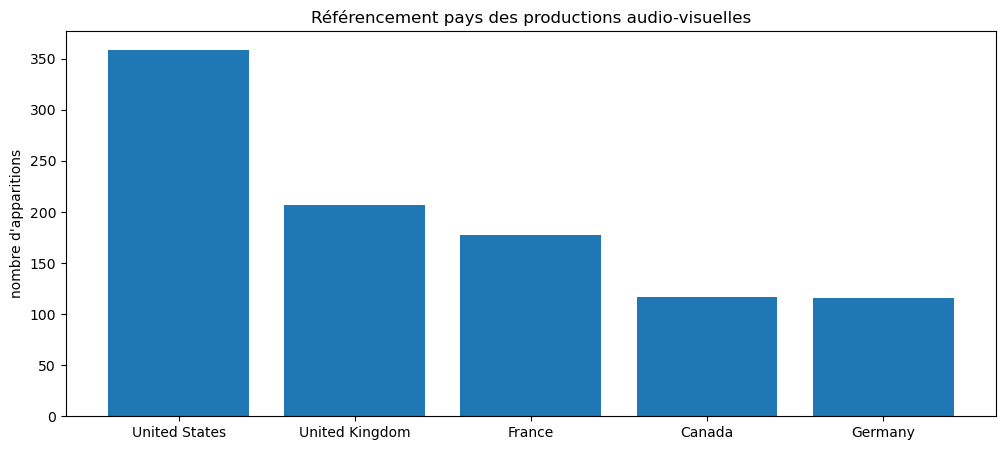

In [13]:
#bar plot des pays les plus fréquents

countries_to_plot = sorted_countries[:5]
countries_to_plot = list(zip(*countries_to_plot))


plt.clf()
plt.figure(figsize=(12, 5))
plt.bar(countries_to_plot[0], countries_to_plot[1])
plt.ylabel('nombre d\'apparitions')
plt.title('Référencement pays des productions audio-visuelles')

plt.savefig('Netflix - Référencement pays des productions audio-visuelles')
plt.show()